In [ ]:
# Task 16: Comparing MSE and BCE using Banknote Authentication Dataset

import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Load dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"

columns = [
    "Variance",
    "Skewness",
    "Curtosis",
    "Entropy",
    "Class"
]

data = pd.read_csv(url, header=None, names=columns)

# Features and labels
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Feature scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Function to build model
def build_model(loss_function):

    model = tf.keras.Sequential([
        tf.keras.layers.Dense(8, activation='relu', input_shape=(4,)),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss=loss_function,
        metrics=['accuracy']
    )

    return model

# Model A (MSE)
model_mse = build_model('mean_squared_error')

history_mse = model_mse.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=0
)

# Model B (BCE)
model_bce = build_model('binary_crossentropy')

history_bce = model_bce.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=0
)

# Evaluate both models
loss_mse, acc_mse = model_mse.evaluate(X_test, y_test, verbose=0)

loss_bce, acc_bce = model_bce.evaluate(X_test, y_test, verbose=0)

print("Model A (MSE)")
print("Test Accuracy:", round(acc_mse*100,2),"%")
print()

print("Model B (BCE)")
print("Test Accuracy:", round(acc_bce*100,2),"%")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model A (MSE)
Test Accuracy: 98.55 %

Model B (BCE)
Test Accuracy: 99.64 %


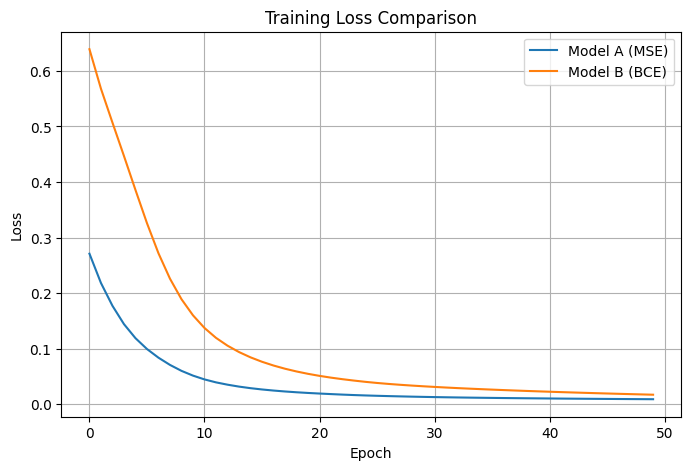

In [ ]:
# Task 17: Compare Training Loss

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history_mse.history['loss'], label='Model A (MSE)')
plt.plot(history_bce.history['loss'], label='Model B (BCE)')

plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()